In [1]:
import importlib
import cosinorage as csa

import utils
importlib.reload(utils)
from utils import recompute_wear_periods, plot_pig_wear_timeseries, save_modified_timeseries, compare_cohorts_daily_signal, load_cohort_data, plot_cohort_feature_comparison, filter_samples_by_wear_time_and_outliers, plot_cohort_demographics

### Computation of wear periods

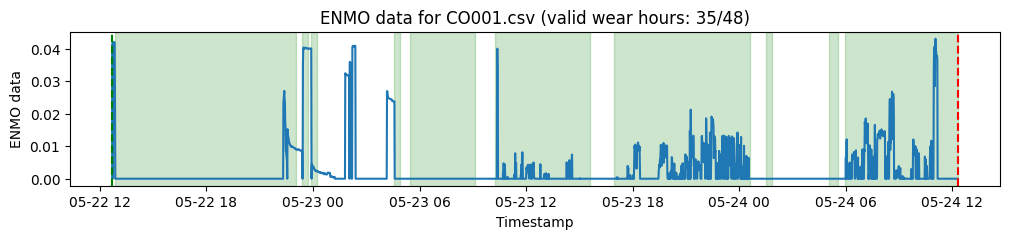

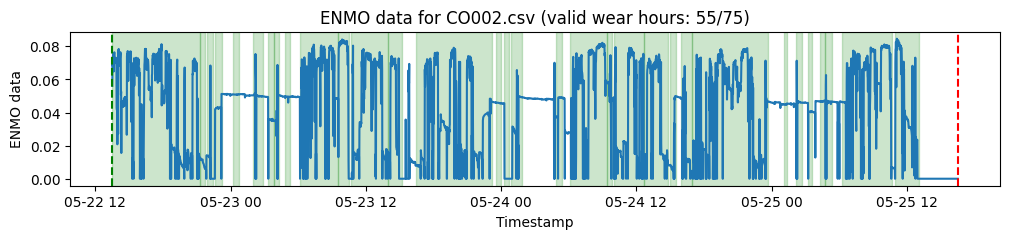

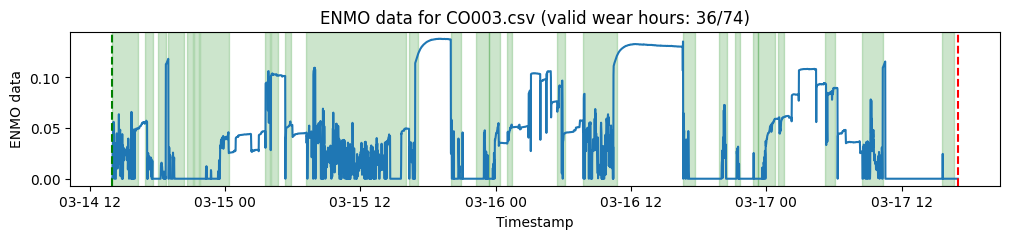

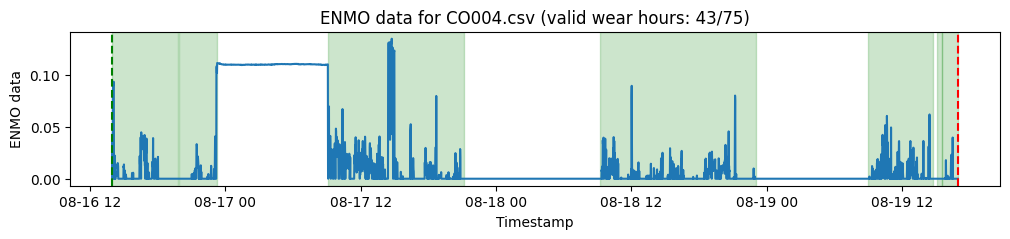

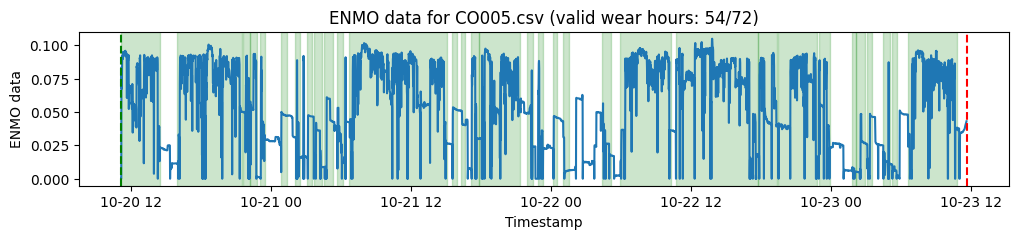

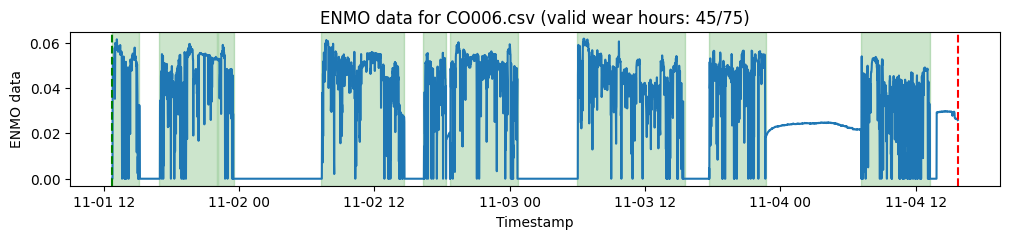

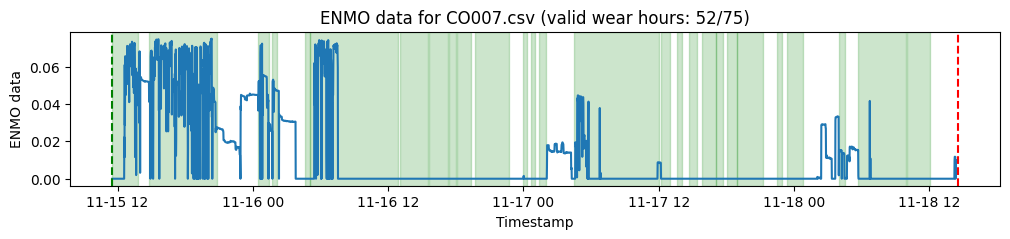

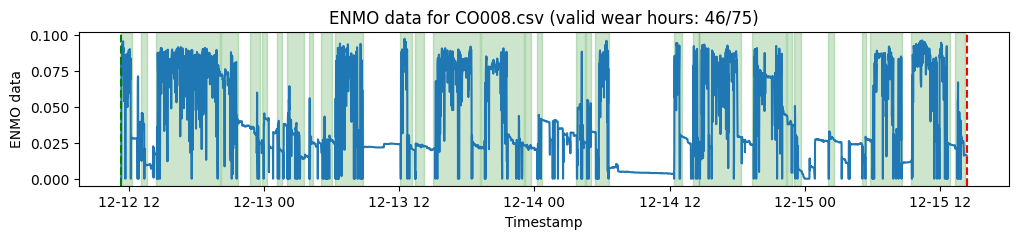

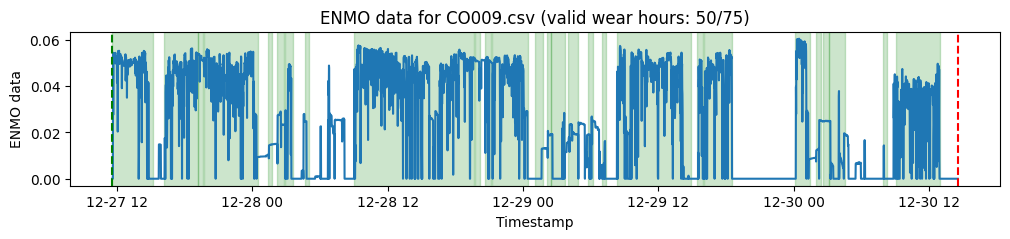

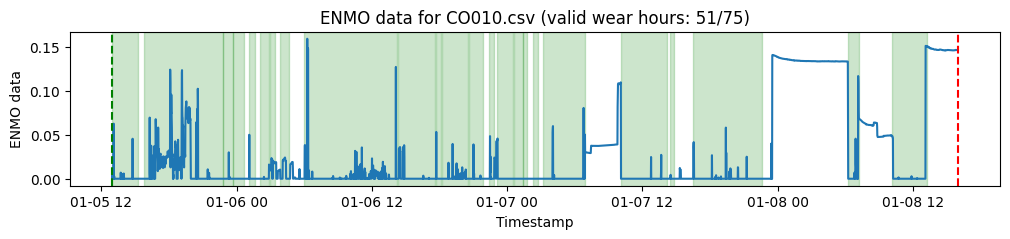

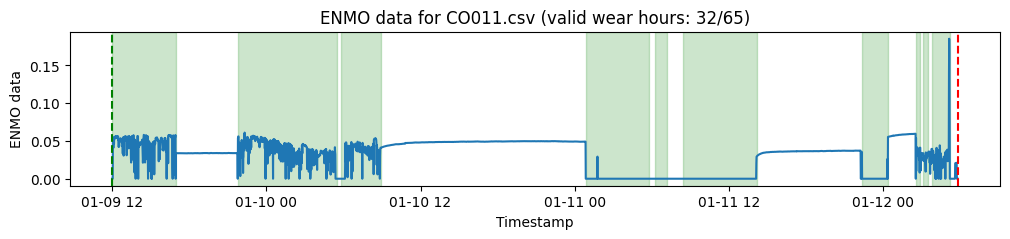

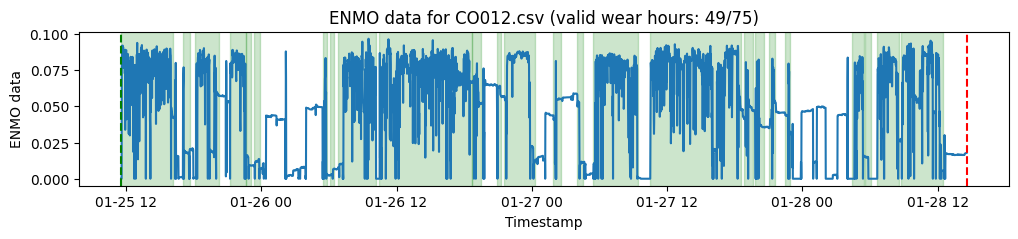

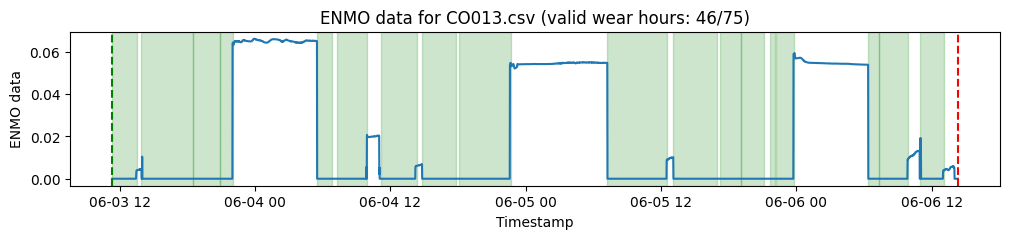

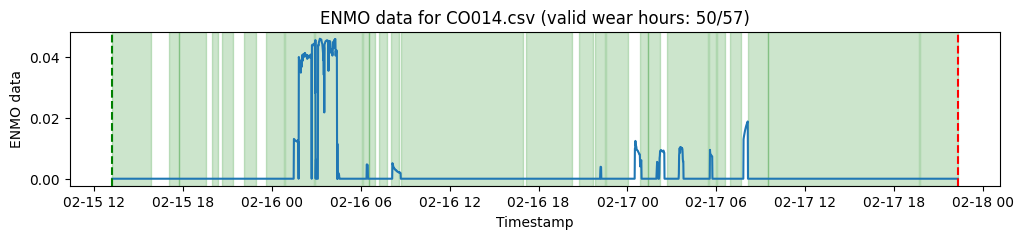

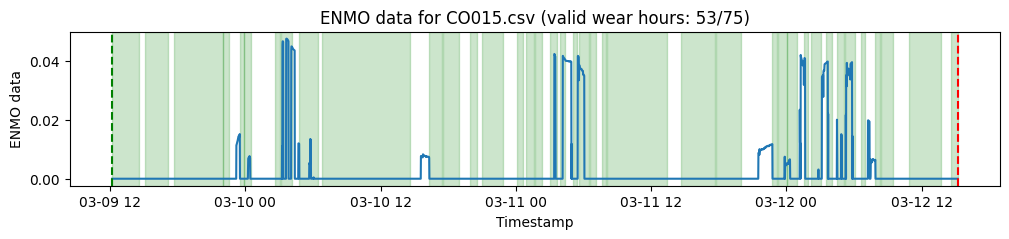

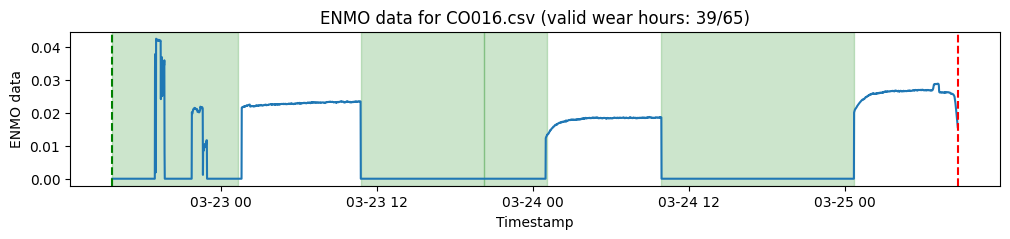

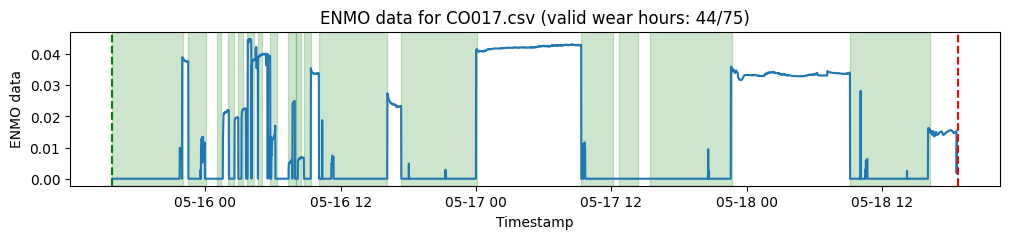

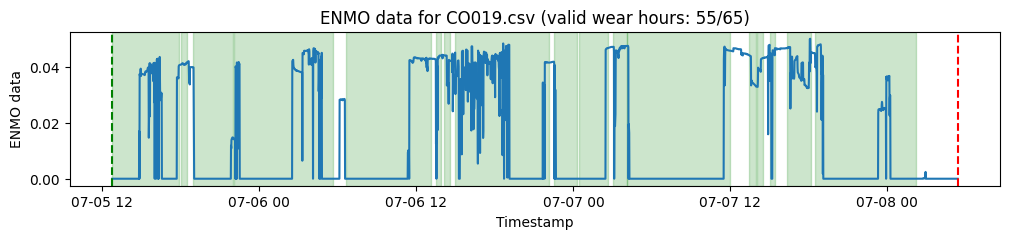

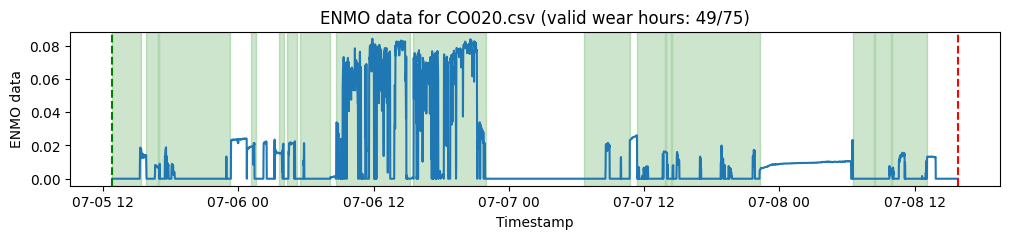

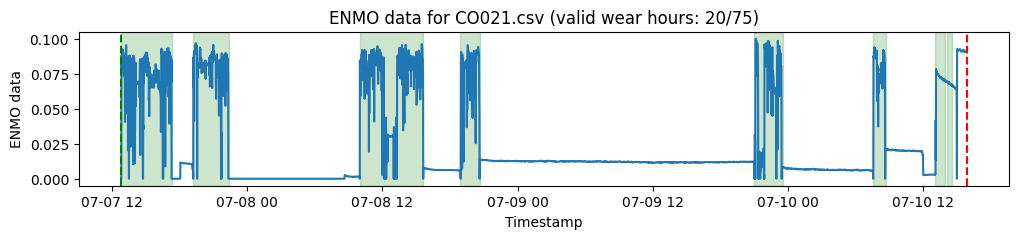

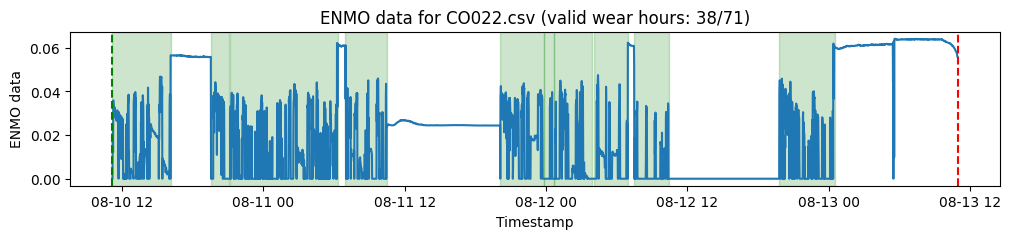

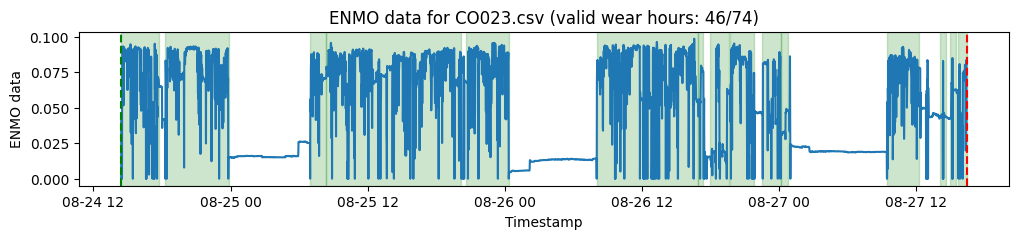

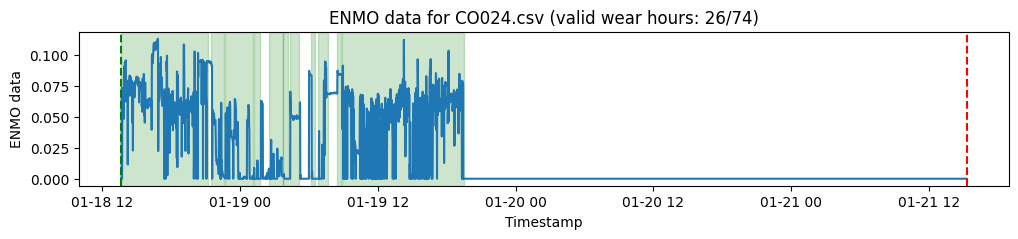

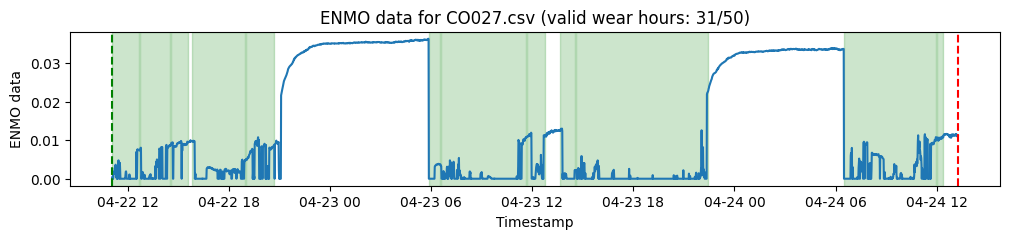

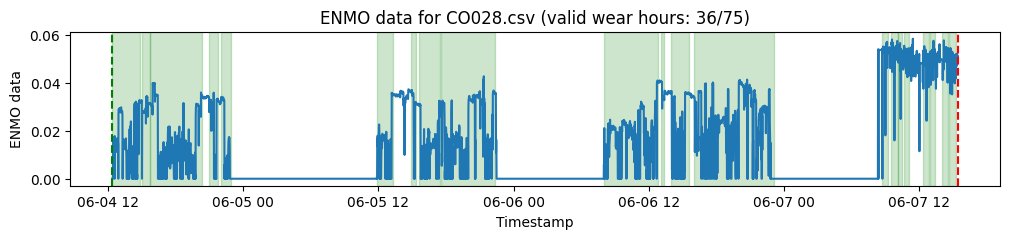

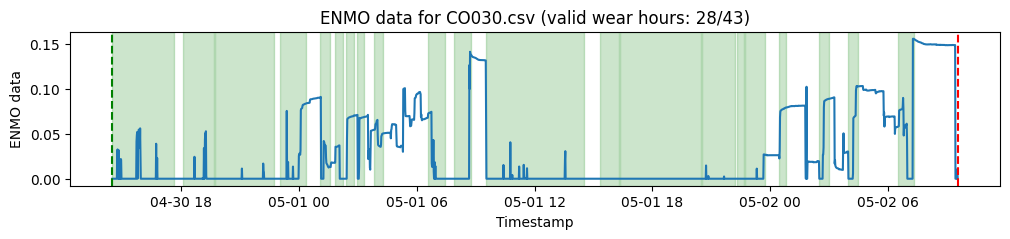

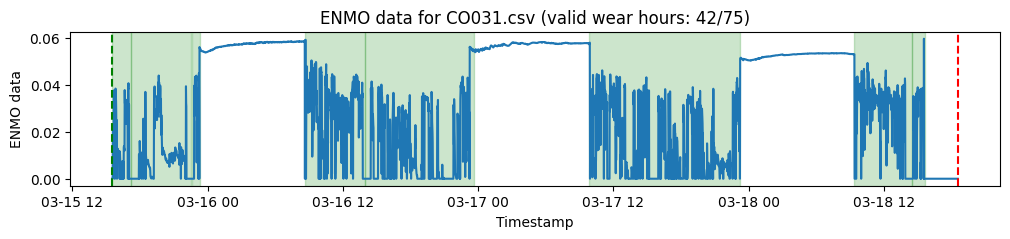

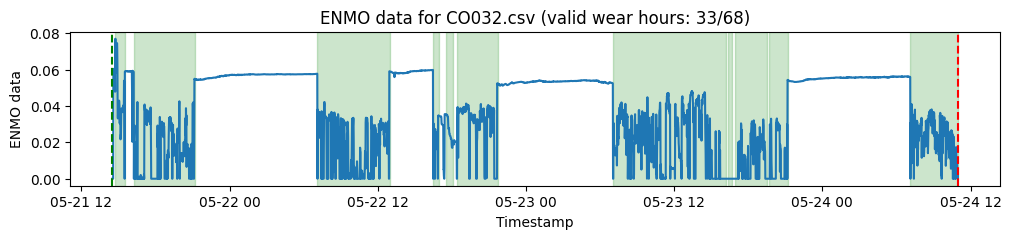

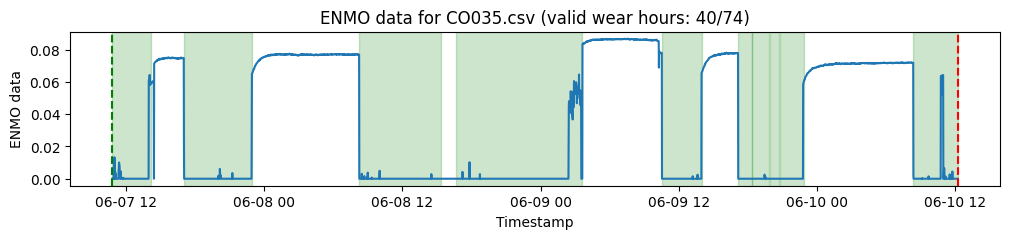

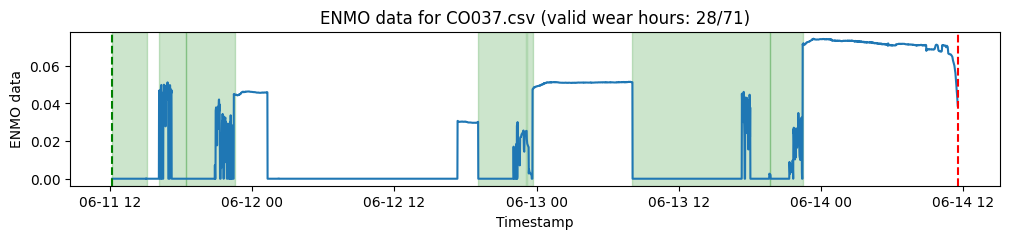

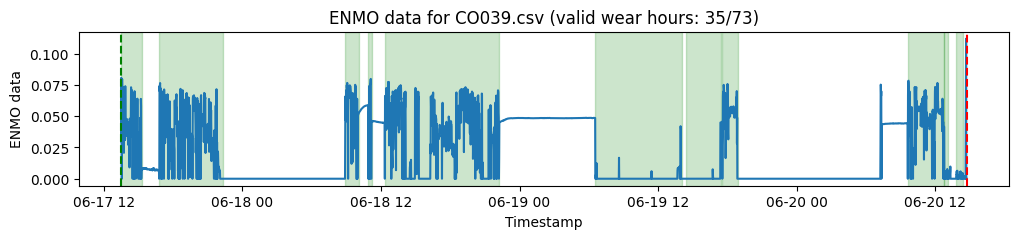

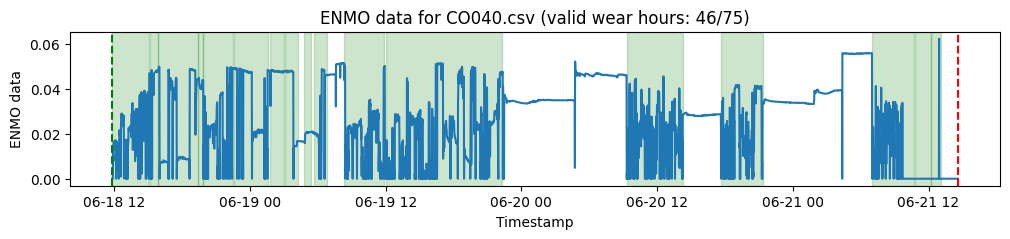

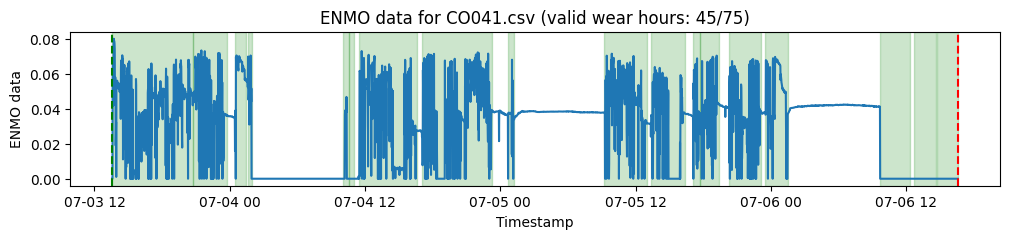

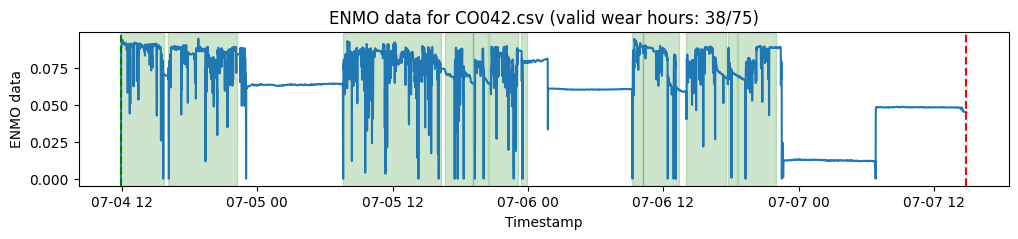

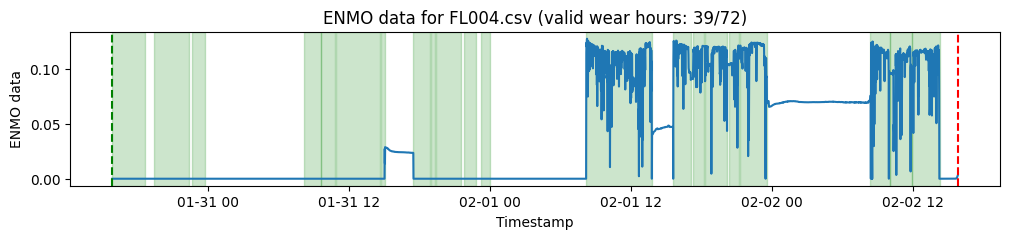

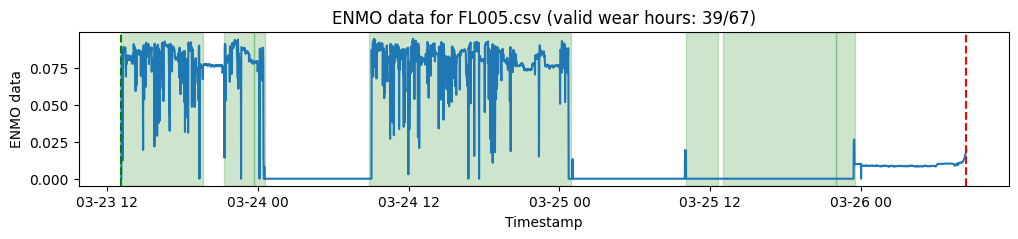

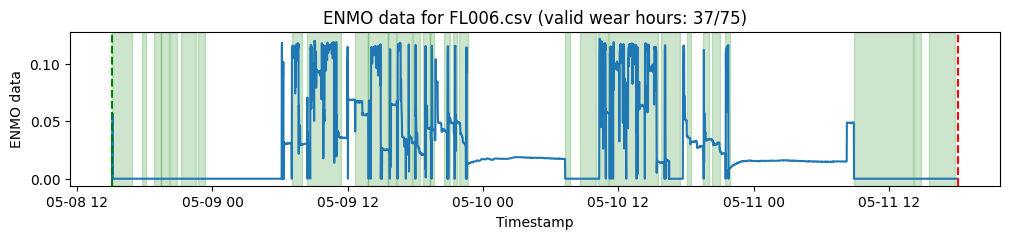

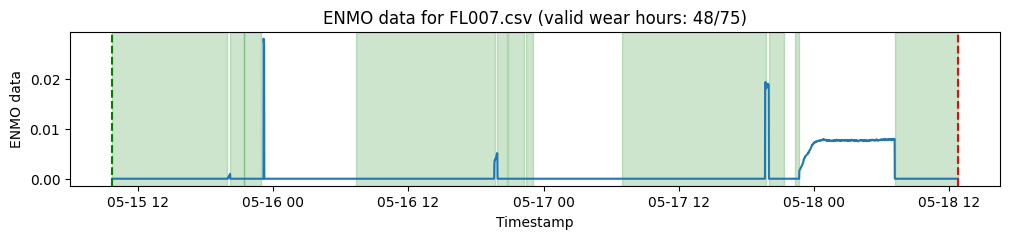

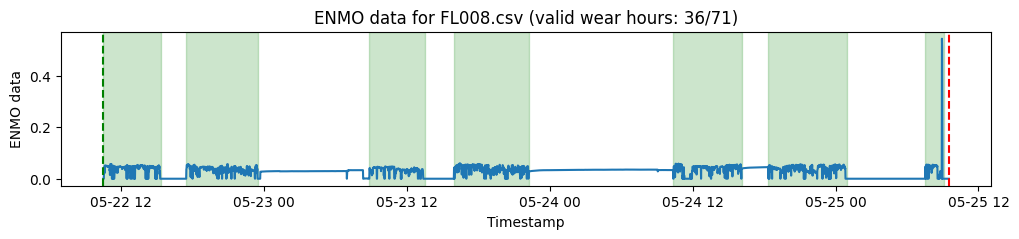

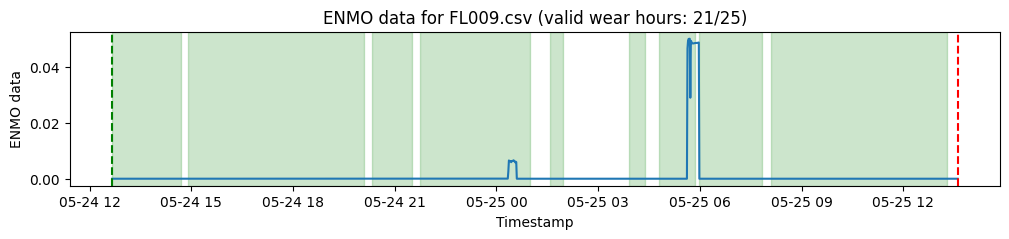

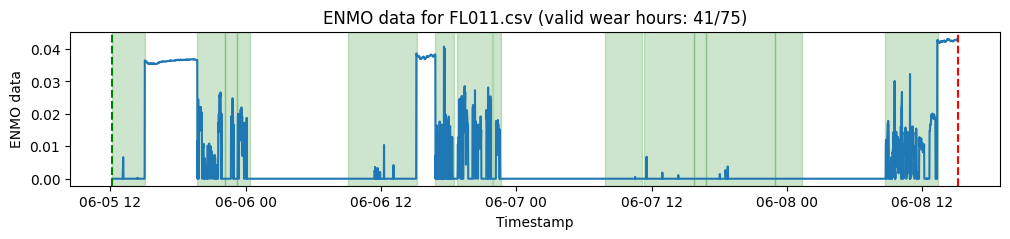

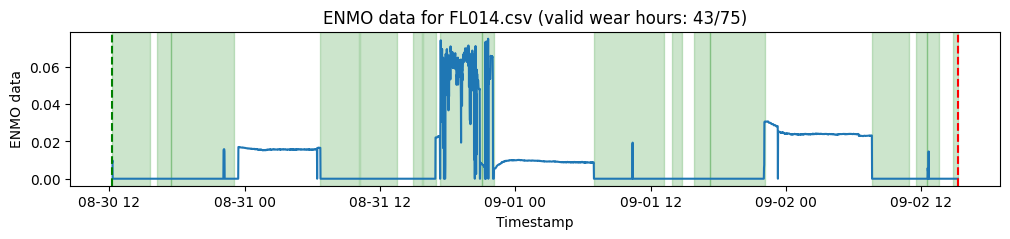

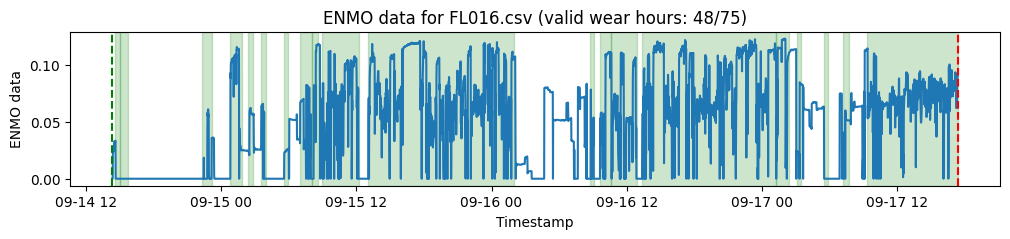

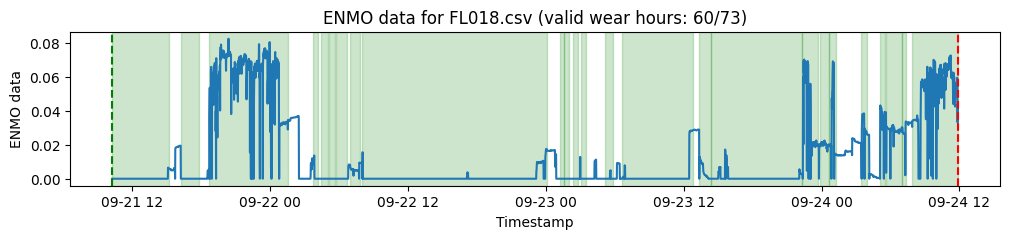

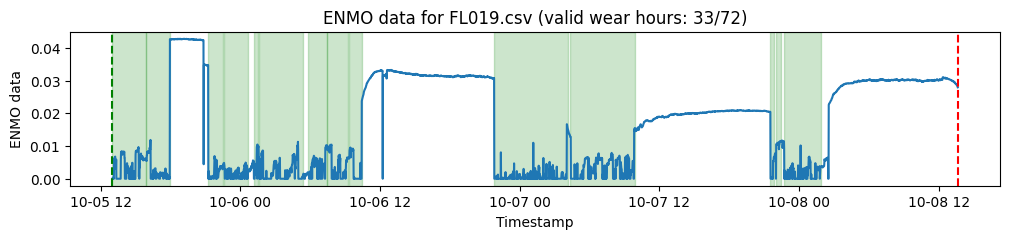

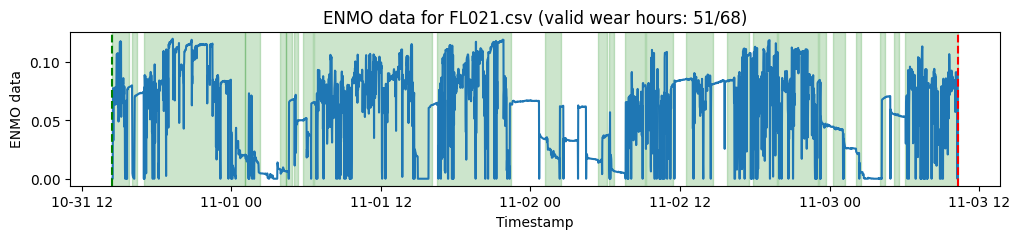

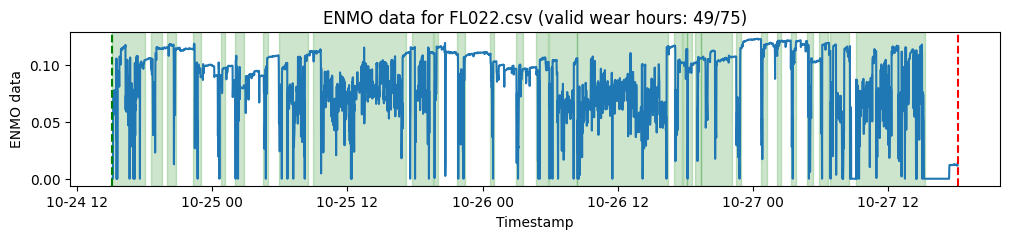

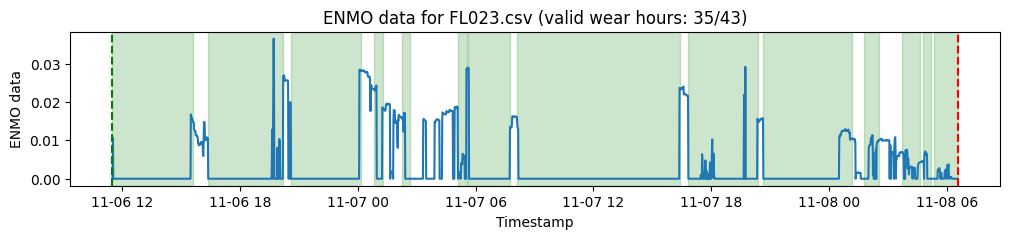

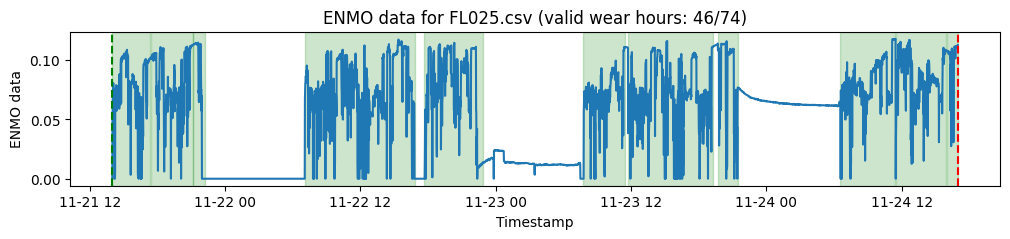

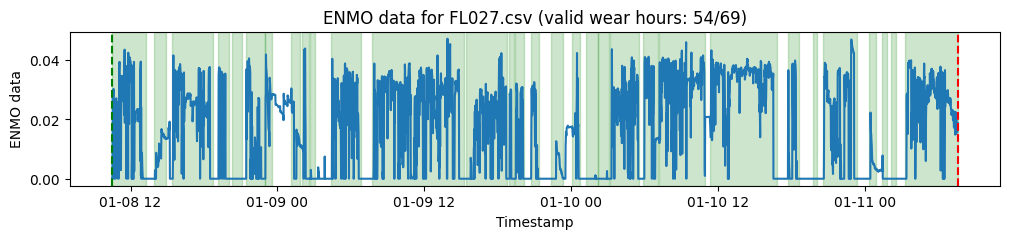

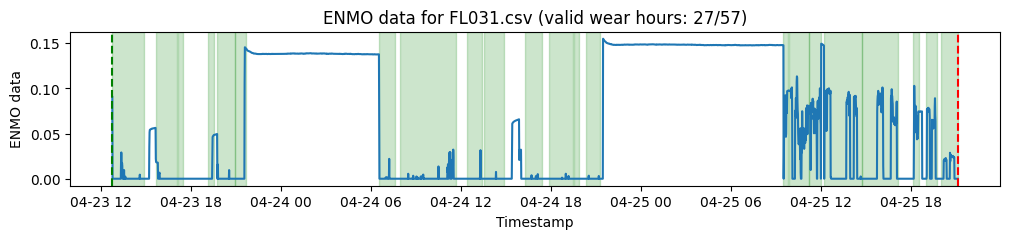

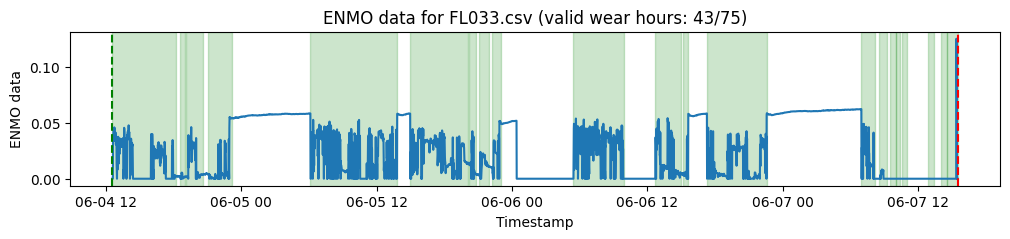

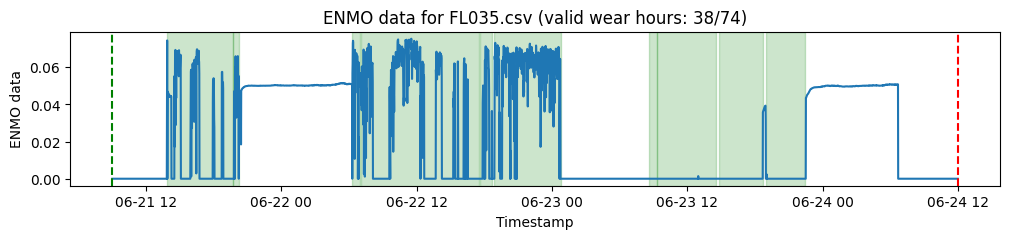

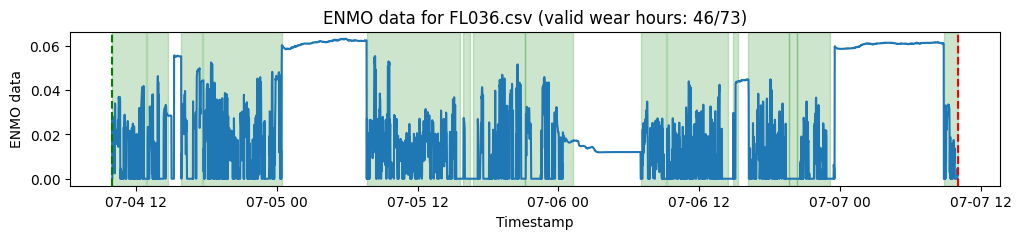

In [2]:
recompute_wear_periods(    
    sd_crit=0.015,
    range_crit=0.001,
    window_length=20,
    min_duration_minutes_wear=20
)
plot_pig_wear_timeseries("wear_periods_recomputed.csv", "minute_level", limit=None, axis='enmo')

### Modification of values during during non-wear periods

During day time the mean of the timeseries is taken and during night time the values are set to 0.


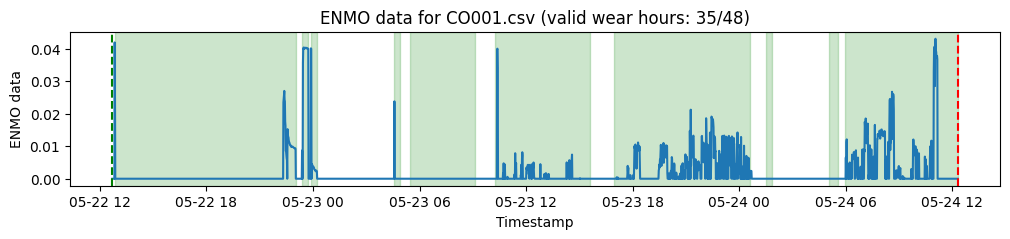

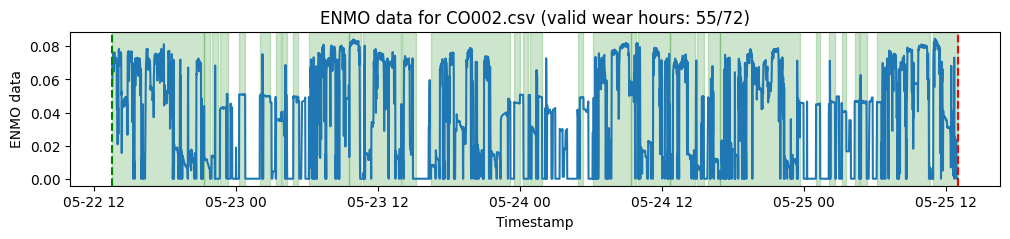

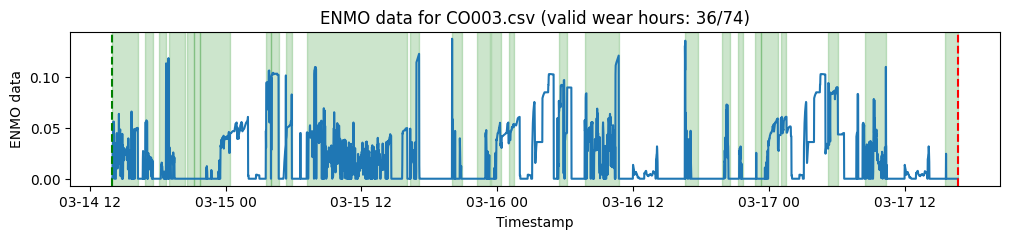

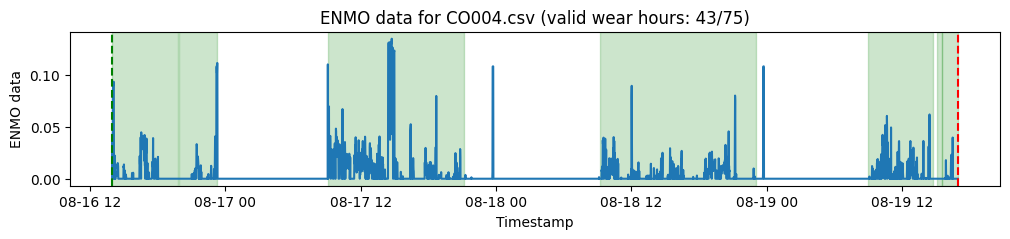

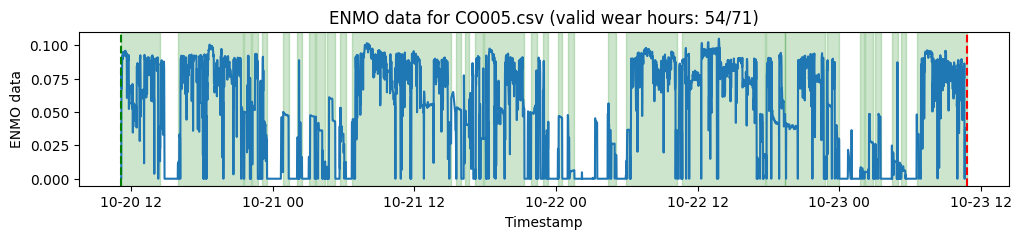

In [3]:
save_modified_timeseries("wear_periods_recomputed.csv", "minute_level", output_dir="minute_level_modified", max_wear_periods=1000, day_start="07:00", day_end="22:00", smart=True)
plot_pig_wear_timeseries("wear_periods_recomputed.csv", "minute_level_modified", limit=5, axis='enmo')

### Filter for samples with > 50% wear time and filter out outlier

In [4]:
file_names = filter_samples_by_wear_time_and_outliers(
    wear_csv="wear_periods_recomputed.csv",
    input_dir="minute_level",
    min_wear_percentage=50.0,
    outlier_method="iqr",
    outlier_threshold=1.5,
    output_file="filtered_samples.csv",
    verbose=False
)
print(file_names)

['CO002.csv', 'CO004.csv', 'CO005.csv', 'CO006.csv', 'CO007.csv', 'CO008.csv', 'CO009.csv', 'CO010.csv', 'CO012.csv', 'CO014.csv', 'CO015.csv', 'CO016.csv', 'CO017.csv', 'CO020.csv', 'CO022.csv', 'CO023.csv', 'CO027.csv', 'CO031.csv', 'CO035.csv', 'CO040.csv', 'CO041.csv', 'CO042.csv', 'FL005.csv', 'FL007.csv', 'FL008.csv', 'FL009.csv', 'FL011.csv', 'FL014.csv', 'FL016.csv', 'FL018.csv', 'FL021.csv', 'FL022.csv', 'FL023.csv', 'FL025.csv', 'FL027.csv', 'FL033.csv', 'FL035.csv', 'FL036.csv']


In [5]:
file_names = [
    "CO002.csv", "CO003.csv", "CO004.csv", "CO005.csv", "CO006.csv", "CO007.csv", "CO008.csv", "CO009.csv", "CO010.csv", "CO011.csv", "CO012.csv",
    "CO019.csv", "CO020.csv", "CO022.csv", "CO023.csv", "CO027.csv", "CO028.csv", "CO031.csv", "CO032.csv", "CO039.csv", "CO040.csv", "CO041.csv", "CO042.csv",
    "FL005.csv", "FL006.csv", "FL008.csv", "FL011.csv", "FL016.csv", "FL019.csv", "FL021.csv", "FL022.csv", "FL025.csv", "FL033.csv", "FL035.csv", "FL036.csv"
]

### Average circadian rhythm per cohort 

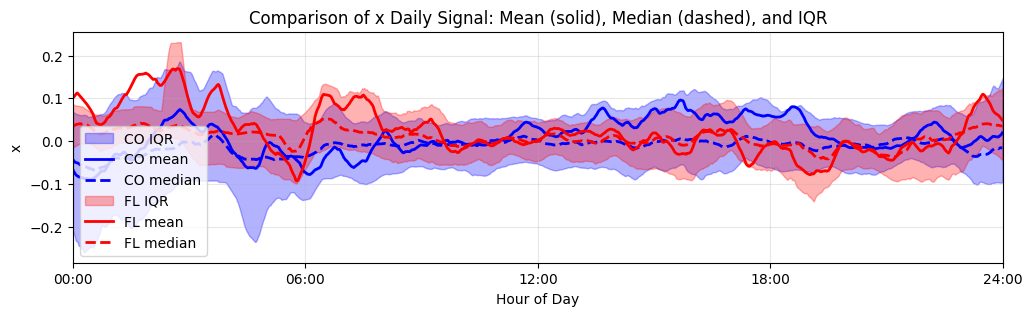

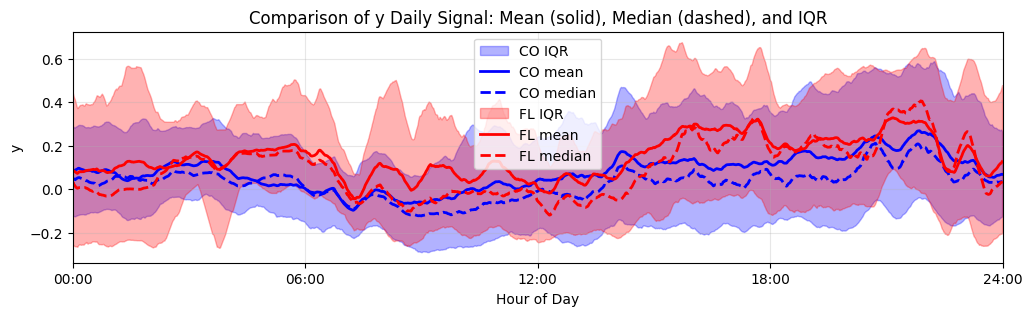

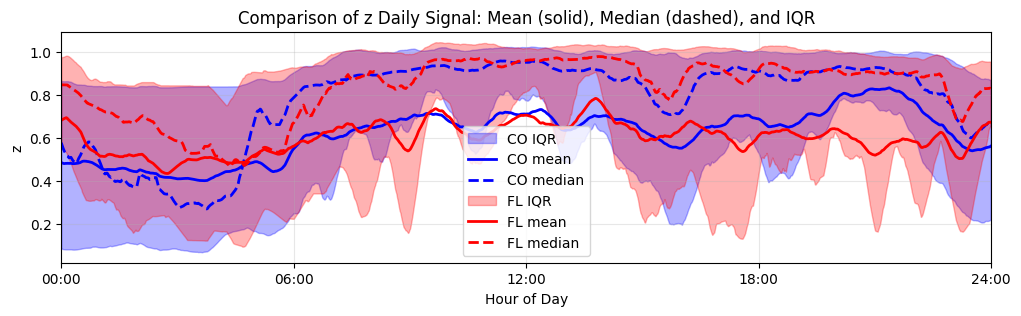

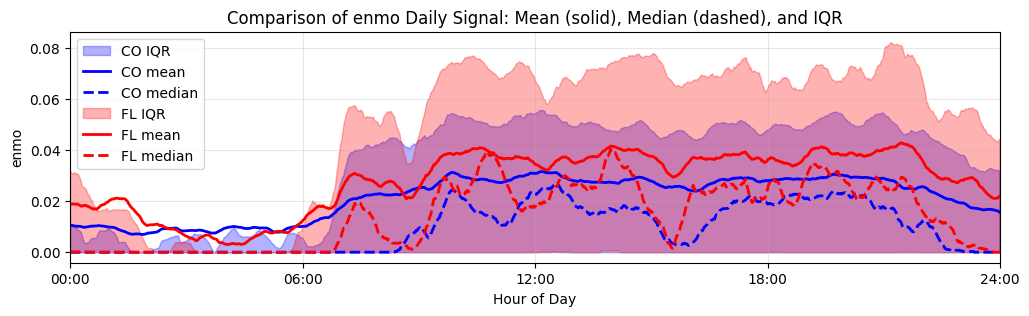

In [6]:
compare_cohorts_daily_signal(co_pattern="CO*.csv", fl_pattern="FL*.csv", folder="minute_level_modified", columns=['x','y','z','enmo'], window=30, plot_minmax=False, file_names=file_names)

### CosinorAge analysis per cohort

In [7]:
co_handlers, co_cosinor_age_inputs = load_cohort_data(modified_dir="minute_level_modified", header_dir="headers", pattern="CO*.csv", preprocess_args=None, file_names=file_names)
fl_handlers, fl_cosinor_age_inputs = load_cohort_data(modified_dir="minute_level_modified", header_dir="headers", pattern="FL*.csv", preprocess_args=None, file_names=file_names)

features_args = {}

co_features = csa.features.BulkWearableFeatures(
    handlers=co_handlers, 
    features_args=features_args,
    compute_distributions=True,
    cosinor_age_inputs=co_cosinor_age_inputs
    )

fl_features = csa.features.BulkWearableFeatures(
    handlers=fl_handlers, 
    features_args=features_args,
    compute_distributions=True,
    cosinor_age_inputs=fl_cosinor_age_inputs
    )

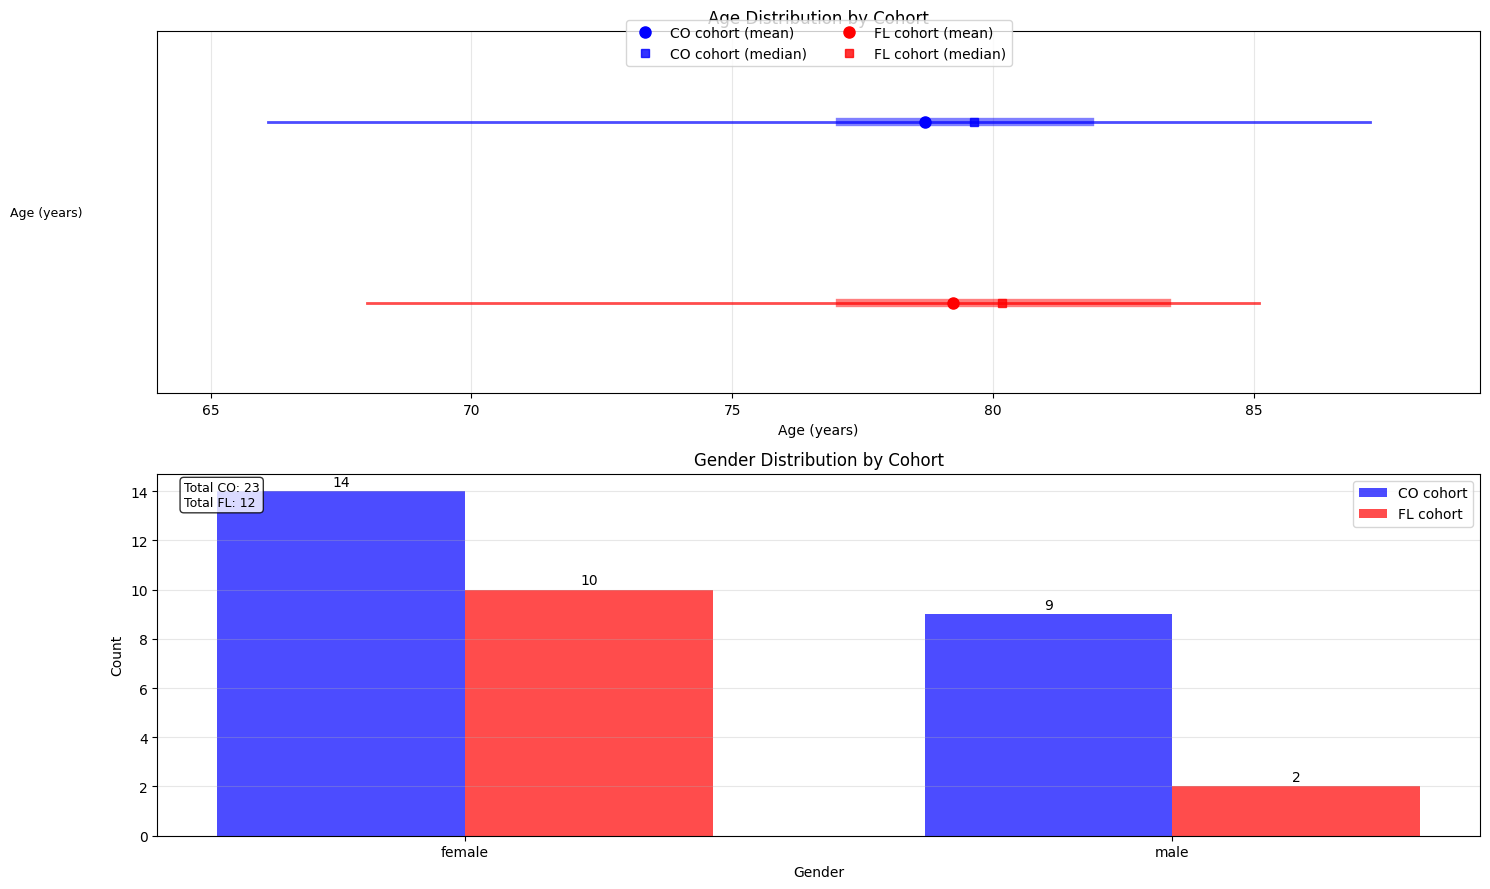

In [8]:
plot_cohort_demographics(co_cosinor_age_inputs=co_cosinor_age_inputs, fl_cosinor_age_inputs=fl_cosinor_age_inputs)

In [9]:
co_features.get_summary_dataframe()

,feature,count,mean,std,min,max,median,q25,q75,iqr,mode,skewness
0,cosinor_mesor,23,21.098835,16.132227,0.847215,51.134724,14.178459,9.140753,32.410704,23.269950,0.847215,0.742901
1,cosinor_amplitude,23,13.746534,10.208658,0.847156,40.396012,10.201379,7.130557,16.702770,9.572213,0.847156,1.159746
2,cosinor_acrophase,23,-3.434089,1.302209,-6.068051,-0.452479,-3.782880,-4.162801,-3.000686,1.162114,-6.068051,0.699083
3,cosinor_acrophase_time,23,787.035312,298.444403,103.700563,1390.694885,866.972238,687.706688,954.043664,266.336976,103.700563,-0.699083
4,nonparam_IS,23,0.768844,0.161425,0.339866,1.000000,0.826491,0.666864,0.875679,0.208815,1.000000,-0.921445
5,nonparam_IV,23,0.934135,0.486370,0.155284,2.158013,0.765861,0.603794,1.267876,0.664081,0.155284,0.898257
6,nonparam_M10,23,32.506682,22.652041,1.657797,78.123296,24.416951,18.191927,43.129658,24.937731,1.657797,0.767035
7,nonparam_L5,23,3.140066,5.600755,0.000000,21.850155,0.000000,0.000000,2.918837,2.918837,0.000000,2.121851
8,nonparam_RA,23,0.874033,0.185937,0.363829,1.000000,1.000000,0.795793,1.000000,0.204207,1.000000,-1.607499
9,physical_activity_sedentary,23,765.065217,310.924893,305.000000,1302.500000,793.000000,466.500000,1009.250000,542.750000,305.000000,0.115195


In [10]:
fl_features.get_summary_dataframe()

,feature,count,mean,std,min,max,median,q25,q75,iqr,mode,skewness
0,cosinor_mesor,12,31.159131,21.745797,1.018063,67.850556,28.493592,13.162744,50.819569,37.656825,1.018063,0.100775
1,cosinor_amplitude,12,19.846353,15.973394,1.495256,45.840897,17.854393,4.335770,33.554495,29.218725,1.495256,0.340716
2,cosinor_acrophase,12,-4.021578,0.873344,-5.140677,-1.518939,-4.153120,-4.450845,-3.867329,0.583516,-5.140677,1.978165
3,cosinor_acrophase_time,12,921.677899,200.155591,348.115265,1178.156290,951.825004,886.326518,1020.058588,133.732070,348.115265,-1.978165
4,nonparam_IS,12,0.798290,0.159137,0.421284,1.000000,0.814463,0.714350,0.903051,0.188701,1.000000,-0.908592
5,nonparam_IV,12,0.737094,0.360503,0.241350,1.458387,0.623716,0.468120,1.033997,0.565877,0.241350,0.691849
6,nonparam_M10,12,46.187114,30.746623,2.337055,82.212950,45.933292,17.818854,78.483094,60.664240,2.337055,-0.186503
7,nonparam_L5,12,5.086734,11.459882,0.000000,41.737829,0.000000,0.000000,2.961368,2.961368,0.000000,3.078205
8,nonparam_RA,12,0.884753,0.190258,0.326546,1.000000,1.000000,0.852031,1.000000,0.147969,1.000000,-2.320660
9,physical_activity_sedentary,12,663.500000,291.033360,239.500000,1330.000000,634.500000,487.000000,808.625000,321.625000,239.500000,0.848550


In [11]:
co_features.get_feature_correlation_matrix()

,cosinor_mesor,cosinor_amplitude,cosinor_acrophase,cosinor_acrophase_time,nonparam_IS,nonparam_IV,nonparam_M10,nonparam_L5,nonparam_RA,physical_activity_sedentary,...,physical_activity_moderate,physical_activity_vigorous,sleep_TST,sleep_WASO,sleep_PTA,sleep_NWB,sleep_SOL,sleep_SRI,cosinorage,cosinorage_advance
cosinor_mesor,1.000000,0.846920,-0.258172,0.258172,0.507508,-0.355271,0.986716,0.614736,-0.365959,-0.881529,...,-0.277004,0.883868,-0.763714,0.661927,-0.763711,-0.529797,-0.441578,0.616731,-0.503291,-0.750201
cosinor_amplitude,0.846920,1.000000,-0.210230,0.210230,0.432743,-0.555670,0.910475,0.203326,0.072552,-0.604320,...,-0.338255,0.607784,-0.521923,0.374874,-0.521920,-0.522467,-0.332082,0.440057,-0.612720,-0.812147
cosinor_acrophase,-0.258172,-0.210230,1.000000,-1.000000,-0.099450,0.194999,-0.243700,-0.109321,0.134729,0.388757,...,0.276758,-0.390946,0.493542,-0.337929,0.493543,0.190551,-0.170440,0.190088,-0.090630,0.189303
cosinor_acrophase_time,0.258172,0.210230,-1.000000,1.000000,0.099450,-0.194999,0.243700,0.109321,-0.134729,-0.388757,...,-0.276758,0.390946,-0.493542,0.337929,-0.493543,-0.190551,0.170440,-0.190088,0.090630,-0.189303
nonparam_IS,0.507508,0.432743,-0.099450,0.099450,1.000000,-0.263119,0.485004,0.157199,-0.030070,-0.606565,...,0.168866,0.603853,-0.657797,0.476788,-0.657798,-0.283504,-0.009031,0.490592,-0.267080,-0.480764
nonparam_IV,-0.355271,-0.555670,0.194999,-0.194999,-0.263119,1.000000,-0.428225,0.188648,-0.440792,0.317860,...,0.118269,-0.319289,0.328736,-0.114679,0.328736,0.647645,-0.017811,-0.147516,0.280546,0.449763
nonparam_M10,0.986716,0.910475,-0.243700,0.243700,0.485004,-0.428225,1.000000,0.537848,-0.255481,-0.829497,...,-0.347248,0.832707,-0.718403,0.604634,-0.718400,-0.576075,-0.398139,0.566762,-0.512675,-0.776507
nonparam_L5,0.614736,0.203326,-0.109321,0.109321,0.157199,0.188648,0.537848,1.000000,-0.868220,-0.670724,...,-0.248882,0.673044,-0.589139,0.743891,-0.589137,-0.137003,-0.399040,0.384858,-0.074094,-0.281845
nonparam_RA,-0.365959,0.072552,0.134729,-0.134729,-0.030070,-0.440792,-0.255481,-0.868220,1.000000,0.505897,...,0.122151,-0.506787,0.394395,-0.587384,0.394394,-0.170543,0.428566,-0.350445,-0.033097,0.042811
physical_activity_sedentary,-0.881529,-0.604320,0.388757,-0.388757,-0.606565,0.317860,-0.829497,-0.670724,0.505897,1.000000,...,0.092645,-0.999938,0.936613,-0.800609,0.936612,0.413116,0.280096,-0.526345,0.388018,0.661350


In [12]:
fl_features.get_feature_correlation_matrix()

,cosinor_mesor,cosinor_amplitude,cosinor_acrophase,cosinor_acrophase_time,nonparam_IS,nonparam_IV,nonparam_M10,nonparam_L5,nonparam_RA,physical_activity_sedentary,...,physical_activity_moderate,physical_activity_vigorous,sleep_TST,sleep_WASO,sleep_PTA,sleep_NWB,sleep_SOL,sleep_SRI,cosinorage,cosinorage_advance
cosinor_mesor,1.000000,0.713974,-0.301214,0.301214,0.517425,-0.004298,0.971961,0.682698,-0.635436,-0.885076,...,-0.437305,0.887610,-0.826296,0.610063,-0.826295,-0.510557,-0.424456,0.645505,-0.715218,-0.972621
cosinor_amplitude,0.713974,1.000000,-0.222540,0.222540,0.620647,-0.518553,0.855556,0.033563,0.029094,-0.557803,...,-0.273823,0.559991,-0.596632,0.273877,-0.596630,-0.650570,-0.095114,0.264334,-0.635078,-0.796323
cosinor_acrophase,-0.301214,-0.222540,1.000000,-1.000000,0.349296,0.508202,-0.286640,-0.148554,0.187850,0.158392,...,0.767710,-0.175805,0.540843,-0.087319,0.540844,0.247024,-0.435475,0.226586,-0.003821,0.236059
cosinor_acrophase_time,0.301214,0.222540,-1.000000,1.000000,-0.349296,-0.508202,0.286640,0.148554,-0.187850,-0.158392,...,-0.767710,0.175805,-0.540843,0.087319,-0.540844,-0.247024,0.435475,-0.226586,0.003821,-0.236059
nonparam_IS,0.517425,0.620647,0.349296,-0.349296,1.000000,-0.057893,0.578382,-0.012416,0.043585,-0.682068,...,0.181480,0.671054,-0.421089,0.291840,-0.421086,-0.354199,-0.429642,0.666302,-0.712258,-0.648868
nonparam_IV,-0.004298,-0.518553,0.508202,-0.508202,-0.057893,1.000000,-0.160922,0.542928,-0.545926,-0.151004,...,0.209909,0.143489,0.126009,0.329287,0.126010,0.459141,-0.569091,0.382058,0.159994,0.099618
nonparam_M10,0.971961,0.855556,-0.286640,0.286640,0.578382,-0.160922,1.000000,0.521441,-0.463765,-0.836009,...,-0.428839,0.838956,-0.809930,0.555721,-0.809929,-0.593283,-0.340088,0.547994,-0.714595,-0.975729
nonparam_L5,0.682698,0.033563,-0.148554,0.148554,-0.012416,0.542928,0.521441,1.000000,-0.954020,-0.593561,...,-0.312467,0.595469,-0.495850,0.641719,-0.495850,-0.106857,-0.507195,0.530349,-0.298740,-0.550521
nonparam_RA,-0.635436,0.029094,0.187850,-0.187850,0.043585,-0.545926,-0.463765,-0.954020,1.000000,0.600883,...,0.312056,-0.602946,0.495773,-0.660652,0.495774,-0.125389,0.605550,-0.594079,0.250233,0.499341
physical_activity_sedentary,-0.885076,-0.557803,0.158392,-0.158392,-0.682068,-0.151004,-0.836009,-0.593561,0.600883,1.000000,...,0.390225,-0.999762,0.878893,-0.714152,0.878893,0.303317,0.524318,-0.771739,0.654916,0.883826


### Feature distribution per cohort

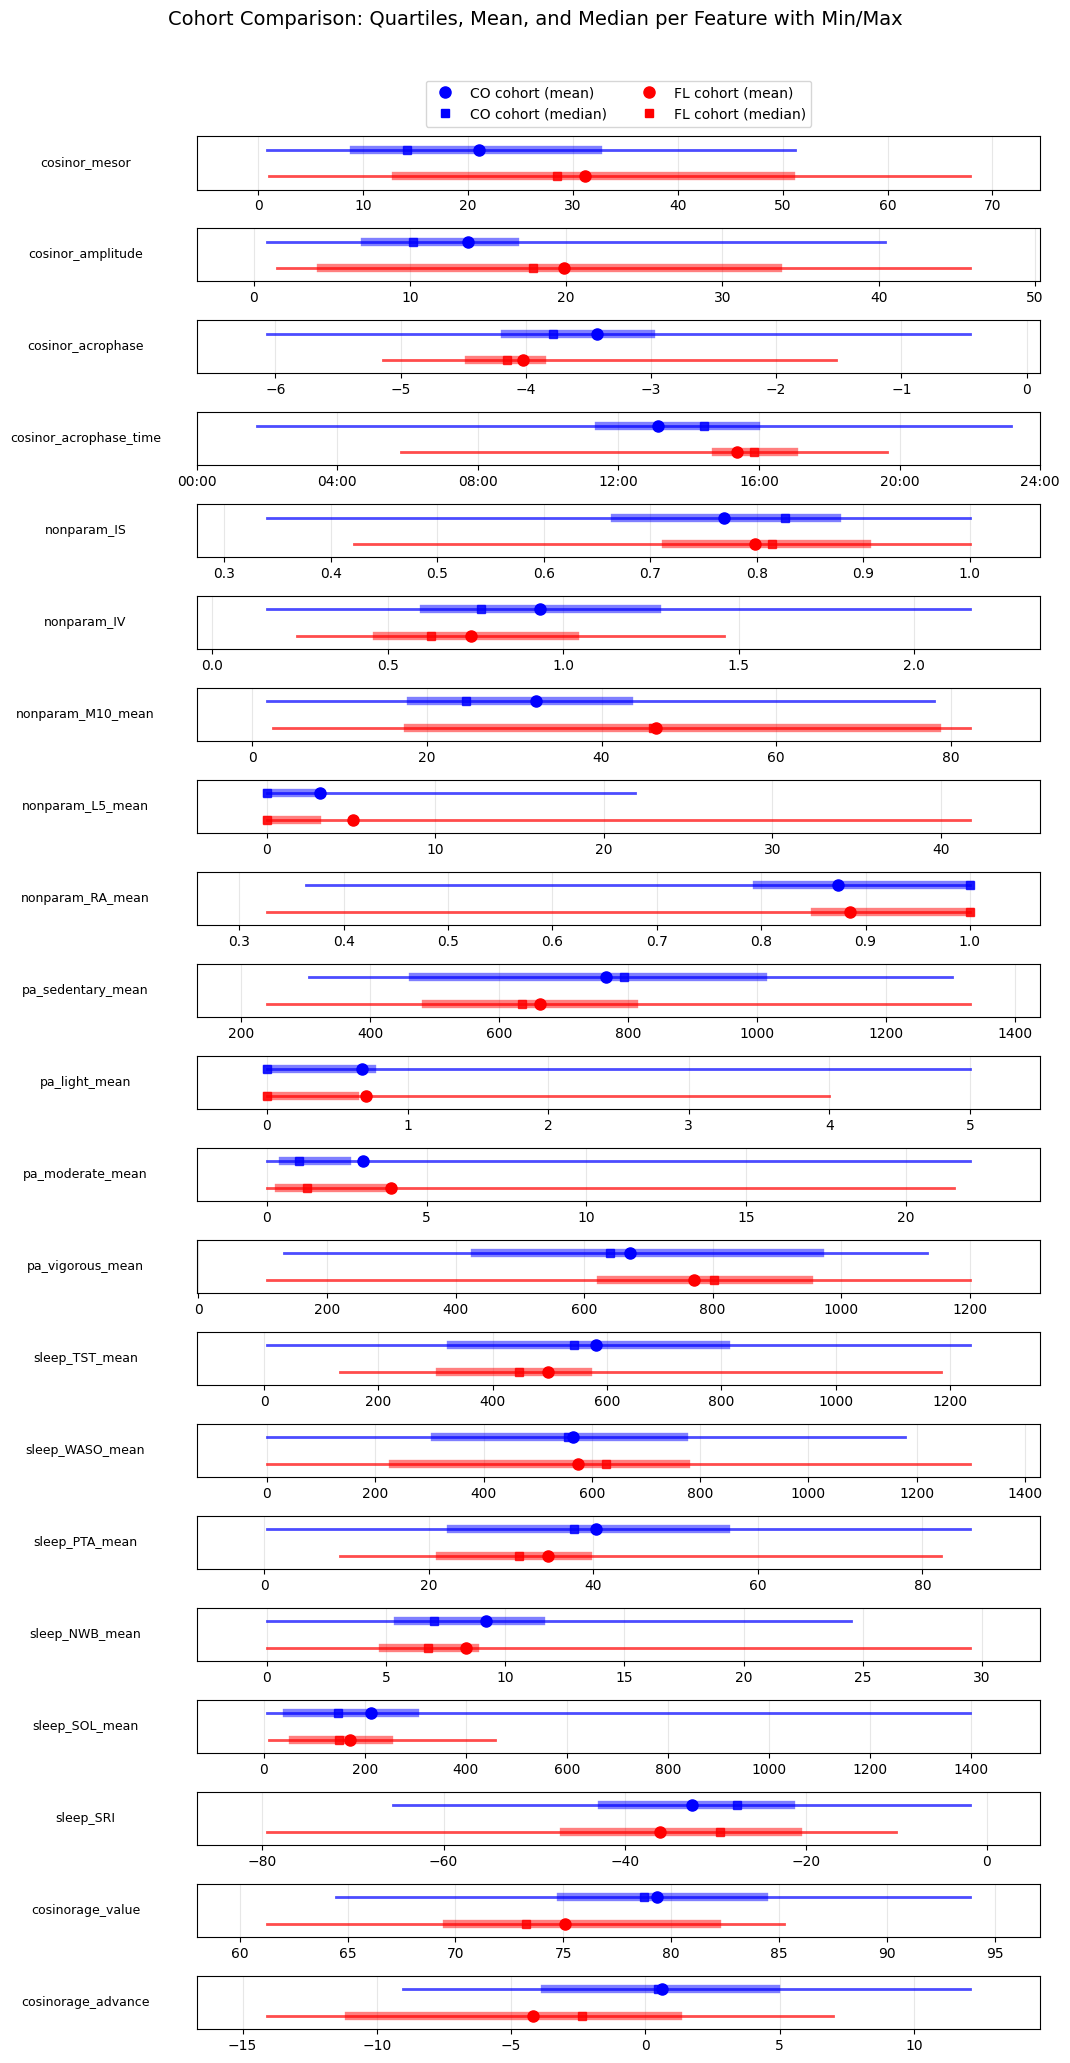

In [13]:
plot_cohort_feature_comparison(co_features, fl_features, title=None, plot_minmax=True)